In [1]:
from typing import List
import re

import numpy as np
from matplotlib import pyplot as plt
import matplotlib

# include the path to the parent directory

import sys
sys.path.append('../../')

from mfgpflow.data_loader import StellarMassFunctions

# set a random number seed to reproducibility
np.random.seed(0)

In [2]:
import numpy as np
from mfgpflow.sb28_smf_loader import SMFDataLoaderSB28, counts_uncertainty_stacked   # <- your class file
from mfgpflow.sb28_smf_loader import SB28Paths, invert_standardizer
# from smf_uncertainty import counts_uncertainty_stacked  # <- your uncertainty fn

In [3]:
basedir = "../../data/SB28/ming-feng/"
#  The SMFs are obtained from the stellar mass of the galaxy catalog, 
# with each binned into 13 bins in the range [108.9, 1011.4] M⊙ which Leja et al. (2020) aims at.
log10M = np.array([
    8.15,  8.45,  8.75,  9.05,  9.35,  9.65, 9.95, 10.25, 10.55, 10.85, 11.15, 11.45, 11.75,
], dtype=np.float32)
snap_numbers = 73, 90

B = len(log10M)  # number of bins

paths = SB28Paths(basedir)
# paths.basedir = basedir

loader = SMFDataLoaderSB28(
    paths,
    log10M_centers=log10M,
    snapshots=snap_numbers,
    bin_edges=None,
    Lbox_mpc_over_h=25.0,
    y_transform="anscombe",
    standardize_X=True,
    standardize_Y=False,
    standardize_Y_128=True,
)

## Visualize the SB28


In [4]:
loader.sigma_A128.shape, loader.Y128.shape, loader.log10M.shape


((2048, 26), (2048, 26), (13,))

Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 73)')

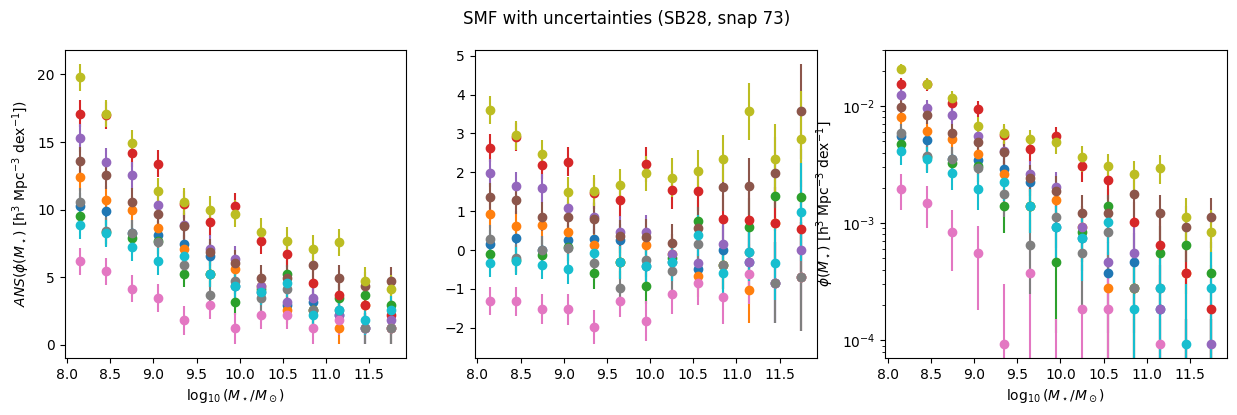

In [5]:
# Snap 73
## Plotting multiple simulations
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(
        log10M,
        invert_standardizer(loader.Y256, loader.Y256_stats)[sim_idx, :len(log10M)],
        yerr=loader.sigma_A256[sim_idx, :len(log10M)],
        fmt='o',
    )

    ax[1].errorbar(
        log10M,
        loader.Y256[sim_idx, :len(log10M)],
        yerr=loader.sigma_A256_standardized[sim_idx, :len(log10M)],
        fmt='o',
    )
    ax[2].errorbar(
        log10M,
        loader.PHI256[sim_idx, :len(log10M)],
        yerr=loader.sigma_phi256_total[sim_idx, :len(log10M)],
        fmt='o',
    )

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[2].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[2].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[2].set_yscale('log')

fig.suptitle("SMF with uncertainties (SB28, snap 73)")
# plt.legend()

Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 90)')

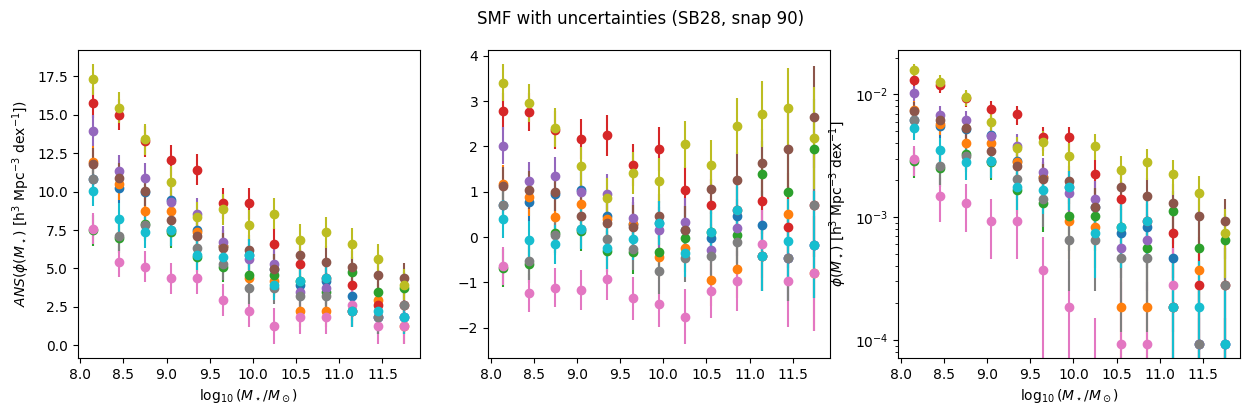

In [6]:
# Snap 73
## Plotting multiple simulations
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(
        log10M,
        invert_standardizer(loader.Y256, loader.Y256_stats)[sim_idx, len(log10M):],
        yerr=loader.sigma_A256[sim_idx, len(log10M):],
        fmt='o',
    )

    ax[1].errorbar(
        log10M,
        loader.Y256[sim_idx, len(log10M):],
        yerr=loader.sigma_A256_standardized[sim_idx, len(log10M):],
        fmt='o',
    )
    ax[2].errorbar(
        log10M,
        loader.PHI256[sim_idx, len(log10M):],
        yerr=loader.sigma_phi256_total[sim_idx, len(log10M):],
        fmt='o',
    )

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[2].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[2].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[2].set_yscale('log')


fig.suptitle("SMF with uncertainties (SB28, snap 90)")
# plt.legend()

## Input space

There are actually logFlag for some dimension, I should make sure the input are linear~

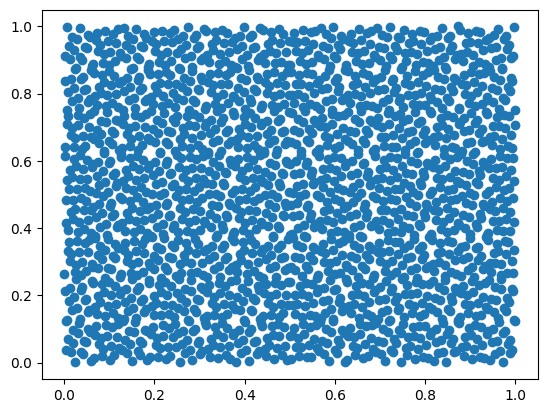

In [7]:
plt.scatter(loader.X128[:, 0], loader.X128[:, 2])

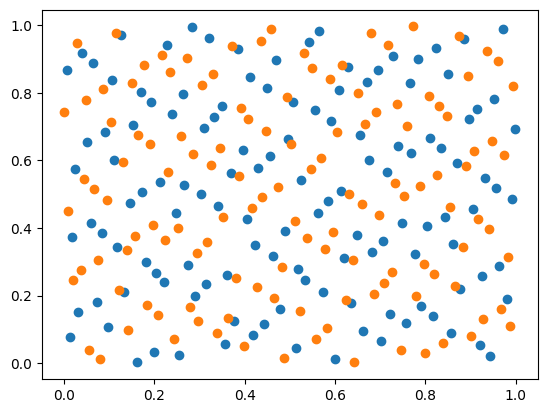

In [8]:
plt.scatter(loader.X128[:128, 10], loader.X128[:128, -10])
plt.scatter(loader.X128[128:256, 10], loader.X128[128:256, -10])

## Demo GP training:

128 -> 256 or 256 -> 512

In [9]:
from mfgpflow.linear_svgp import LatentMFCoregionalizationSVGP
import numpy as np
import gpflow
import tensorflow as tf
from sklearn.cluster import KMeans

In [10]:
loader.X512.shape, loader.Y512.shape, loader.X256.shape, loader.Y256.shape, loader.X128.shape, loader.Y128.shape

((128, 28), (32, 26), (2048, 28), (2048, 26), (2048, 28), (2048, 26))

In [11]:
import numpy as np

def suggest_L_from_Y(Y, thresh=0.95):
    """
    Y: (N, P) targets (stacked snapshots as columns).
    Returns smallest L explaining 'thresh' fraction of variance.
    """
    Yc = Y - Y.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Yc, full_matrices=False)  # S: singular values
    expl = (S**2) / np.sum(S**2)
    cum = np.cumsum(expl)
    L = int(np.searchsorted(cum, thresh) + 1)
    return L, expl, cum

# Example:
L_suggested, expl, cum = suggest_L_from_Y(loader.Y128)  # Y_train shape (N, 26)
print("Suggested L:", L_suggested)

Suggested L: 10


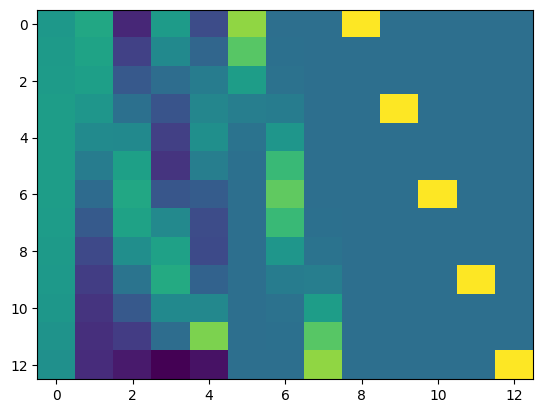

Initial noise variances (heteroscedastic): [0.01215138 0.01189369 0.01159538 0.01166851 0.01155475 0.01152501
 0.01151082 0.01122896 0.01107572 0.01093785 0.01078294 0.0104698
 0.01069414]
Instructions for updating:
Use fn_output_signature instead


2025-08-27 00:29:08.307561: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


🔹 Iteration 0: ELBO = 95986.52923474296
🔹 Iteration 100: ELBO = 37232.8476048461
🔹 Iteration 200: ELBO = 27867.433484782534
🔹 Iteration 300: ELBO = 25179.017233349074
🔹 Iteration 400: ELBO = 23878.465805840762
🔹 Iteration 500: ELBO = 23085.15040323309
🔹 Iteration 600: ELBO = 21428.344365164714
🔹 Iteration 700: ELBO = 21110.74514268461
🔹 Iteration 800: ELBO = 20871.104776170323
🔹 Iteration 900: ELBO = 20696.810687840403
🔹 Iteration 1000: ELBO = 20543.752633877866
🔹 Iteration 1100: ELBO = 20419.415703327508
🔹 Iteration 1200: ELBO = 20304.6597571456
🔹 Iteration 1300: ELBO = 20200.572687422296
🔹 Iteration 1400: ELBO = 20114.06085587768
🔹 Iteration 1500: ELBO = 20030.513535062953
🔹 Iteration 1600: ELBO = 19963.11799970846
🔹 Iteration 1700: ELBO = 19905.672892227412
🔹 Iteration 1800: ELBO = 19853.282986213573
🔹 Iteration 1900: ELBO = 19807.58730762365
🔹 Iteration 2000: ELBO = 19766.33730792074
🔹 Iteration 2100: ELBO = 19729.79836244506
🔹 Iteration 2200: ELBO = 19697.13331114476
🔹 Iteration 2

In [ ]:
# 🔹 1️⃣ Load Data
# parameter dim: 28; output dim: 26
param_dim = loader.X512.shape[1]  # 28 input parameters
test_start = 128 #1024 + 512
test_end = 256 #1024 + 512 + 512
num_latents = 13     # Reduce latent GPs to match HF sparsity
num_inducing = 256  # Reduce inducing points to prevent overfitting
heterosed = True
vector_variance = True

X_LF, Y_LF = loader.X128, loader.Y128 # LF Data (2048, 28) -> (2048, 26)
X_HF, Y_HF = loader.X256[:test_start], loader.Y256[:test_start, :] # HF Data (24, 28) → (24, 26)

# test data: shape (8, 28) -> (8, 26)
X_test_HF, Y_test_HF = loader.X256[test_start:test_end, :], loader.Y256[test_start:test_end, :]

# Only one redshift snapshot is used for training for now
# TODO: Use multiple snapshots for training
Y_LF = Y_LF[:, :len(loader.log10M)]  # Ensure Y_LF has 13 outputs
Y_HF = Y_HF[:, :len(loader.log10M)]  # Ensure Y_HF has 13 outputs
# Noise variance
Var_LF = loader.sigma_A128_standardized[:, :len(loader.log10M)] ** 2  # (2048, 13)
Var_HF = loader.sigma_A256_standardized[:test_start, :len(loader.log10M)] ** 2  # (24, 13)
# Ensure Y_test_HF has 13 outputs
Y_test_HF = Y_test_HF[:, :len(loader.log10M)]  # Ensure Y_test_HF has 13 outputs
Var_test_HF = loader.sigma_A256_standardized[test_start:test_end, :len(loader.log10M)] ** 2  # (8, 13)

# 🔹 2️⃣ Prepare Training Data
n_LF, n_HF = X_LF.shape[0], X_HF.shape[0]  # Number of points
output_dim = Y_LF.shape[1]

# ✅ Append fidelity indicators (0 for LF, 1 for HF)
X_LF_aug = np.hstack([X_LF, np.zeros((n_LF, 1))])  # LF data with fidelity=0
X_HF_aug = np.hstack([X_HF, np.ones((n_HF, 1))])   # HF data with fidelity=1

# ✅ Combine datasets
X_train = np.vstack([X_LF_aug, X_HF_aug])  # Shape: (2072, 29)
Y_train = np.vstack([Y_LF, Y_HF])  # Shape: (2072, 26)
# noise variance
Var_train = np.vstack([Var_LF, Var_HF])  # Shape: (2072, 13)

# 🔹 3️⃣ Define Multi-Fidelity GP Model
# ✅ Define base kernels for LF and HF discrepancy
D_feat = X_train.shape[1] - 1  # drop fidelity flag

# Shared physics (appears in LL, LH, HH via ρ)
kL_long  = gpflow.kernels.Matern52(lengthscales=np.ones(D_feat),      variance=1.0)
kL_short = gpflow.kernels.Matern32(lengthscales=0.12*np.ones(D_feat), variance=0.3)
kernel_L = kL_long + kL_short

# HF‑only discrepancy (only K_HH); lighter to avoid confounding
kD_main  = gpflow.kernels.Matern52(lengthscales=np.ones(D_feat),      variance=0.5)
kD_short = gpflow.kernels.Matern32(lengthscales=0.20*np.ones(D_feat), variance=0.1)
kernel_delta = kD_main + kD_short

# original kernels
# kernel_L = gpflow.kernels.Matern52(lengthscales=np.ones(param_dim), variance=1.0)
# kernel_delta = gpflow.kernels.Matern52(lengthscales=np.ones(param_dim), variance=1.0)

# # ✅ Optimize Inducing Points using K-Means Clustering
# kmeans = KMeans(n_clusters=num_inducing, random_state=42).fit(X_train)
# Z_init = kmeans.cluster_centers_

# Vector variance initialization, such that each output has its own noise variance
if vector_variance:
    variance = np.var(Y_train, axis=0, keepdims=True).flatten() * 0.1 if not heterosed else np.var(Y_train, axis=0, keepdims=True).flatten() * 0.01
else:
    variance = np.array([1.0], dtype=np.float64) if not heterosed else np.array([0.1], dtype=np.float64)

# ✅ Initialize the Latent Multi-Fidelity Coregionalization SVGP model
mf_gp = LatentMFCoregionalizationSVGP(
    X_train, Y_train,
    kernel_L, kernel_delta,
    num_outputs=output_dim, num_latents=num_latents, num_inducing=num_inducing,
    heterosed=True,  # Heteroscedastic noise model,
    variance=variance,  # Initial noise variance
)

########## W Initialization ##########
# B) W with global + local + (near) diagonal columns
# If you push L > P, make the extra columns of W_local and W_diag narrower /
#  more sparse so they capture non‑smooth, bin‑specific effects rather than duplicating global structure.

def windowed_W(P, centers, width_bins):
    idx = np.arange(P)[:, None]
    cen = np.array(centers)[None, :]
    W = np.exp(-0.5 * ((idx - cen) / width_bins) ** 2)
    W /= np.linalg.norm(W, axis=0, keepdims=True) + 1e-8
    return W

P = output_dim
L_global = 5                                # smooth bulk structure
L_local  = 3                                # localized columns
L_diag   = num_latents - L_global - L_local # bin-specific columns
L        = L_global + L_local + L_diag

# Global: PCA on (centered) Y
Yc = Y_train - Y_train.mean(axis=0, keepdims=True)
_, _, Vt = np.linalg.svd(Yc, full_matrices=False)
W_global = Vt[:L_global].T                      # (P, L_global)

# Local: Gaussian windows across bins
centers  = np.linspace(0, P-1, L_local)
W_local  = windowed_W(P, centers, width_bins=1.5)

# (Near) diagonal: give a couple bins one‑hot columns
W_diag = np.zeros((P, L_diag))
hot_bins = np.linspace(0, P-1, L_diag, dtype=int)
# hot_bins = np.linspace(0, L_diag - 1, L_diag, dtype=int)
for j, b in enumerate(hot_bins):
    W_diag[b, j] = 1.0

W_init = np.hstack([W_global, W_local, W_diag]).astype(np.float64) * 0.5
mf_gp.kernel.W.assign(W_init)   # works because top kernel is still LinearCoregionalization

plt.imshow(W_init, aspect="auto")
plt.show()


import time
start = time.time()
if heterosed:
    print("Initial noise variances (heteroscedastic):", mf_gp.likelihood.variance.numpy())
    # 🔹 4️⃣ Train the Model with Adaptive Learning Rate
    mf_gp.optimize(
        (X_train, np.concatenate([Y_train, Var_train], axis=1)),  # Concatenate Y and Var for heteroscedastic case
        max_iters=2000,  # Reduce training iterations
        initial_lr=0.01,  # Lower learning rate for stability
        unfix_noise_after=500,  # Delay unfixing noise variance
        # decay_lr=True  # Enable learning rate decay
    )

else:
    print("Initial noise variance (homoscedastic):", mf_gp.likelihood.variance.numpy())
    # 🔹 4️⃣ Train the Model with Adaptive Learning Rate
    mf_gp.optimize(
        (X_train, Y_train),
        max_iters=2000,  # Reduce training iterations
        initial_lr=0.01,  # Lower learning rate for stability
        unfix_noise_after=500,  # Delay unfixing noise variance
        # decay_lr=True  # Enable learning rate decay
    )

print(f"Training Time: {time.time() - start:.2f} seconds")

In [26]:

mu = Y_train.mean(axis=0, keepdims=True)          # (1, P)
sd = Y_train.std(axis=0, keepdims=True) + 1e-8     # (1, P)

# Y_train_std   = (Y_train - mu) / sd
# Var_train_std = Var_train / (sd**2)                # very important

Loss history

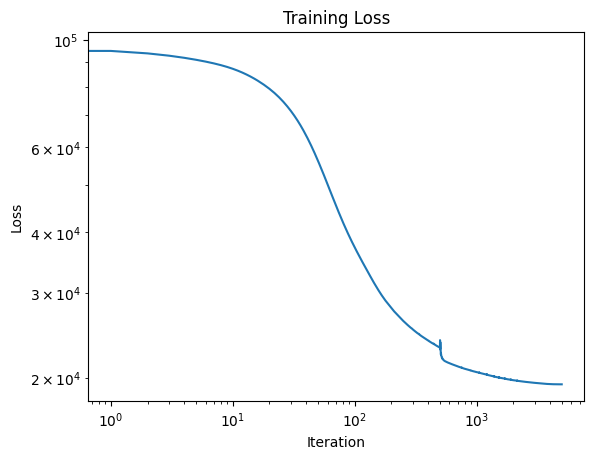

In [13]:
plt.plot(mf_gp.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale('log')
plt.xscale('log')
plt.title("Training Loss")
plt.show()

In [14]:

# 🔹 5️⃣ Make Predictions on HF Test Set
num_test_points = X_test_HF.shape[0]
X_test_HF_aug = np.hstack([X_test_HF, np.ones((num_test_points, 1))])  # Append fidelity indicators
mean_pred, var_pred = mf_gp.predict_f(X_test_HF_aug)


# 🔹 6️⃣ Compute Residuals
residuals = mean_pred.numpy() - Y_test_HF  # Shape: (10, 49)

# ✅ Print summary
print(f"🔍 Final Residuals: {residuals.mean():.4f} ± {residuals.std():.4f}")
print(f"✅ Model trained and predictions completed!")

# ✅ Check Learned W Matrix
print("🔍 Final Learned W Matrix:")
print(mf_gp.kernel.W.numpy())

# ✅ Check Noise Variance
print(f"🔍 Learned noise variance: {mf_gp.likelihood.variance.numpy()}")

# ✅ Evaluate Test Performance
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test_HF, mean_pred.numpy())
print(f"🔍 HF Prediction MSE: {mse:.4f}")

# LF train points
mean_pred_LF, var_pred_LF = mf_gp.predict_f(X_LF_aug)
# HF train points
mean_pred_HF, var_pred_HF = mf_gp.predict_f(X_HF_aug)
# Evaluate training performance
mse_LF = mean_squared_error(Y_LF, mean_pred_LF.numpy())
mse_HF = mean_squared_error(Y_HF, mean_pred_HF.numpy())
print(f"🔍 LF Train MSE: {mse_LF:.4f}")
print(f"🔍 HF Train MSE: {mse_HF:.4f}")

🔍 Final Residuals: 0.0671 ± 0.6834
✅ Model trained and predictions completed!
🔍 Final Learned W Matrix:
[[ 2.54626851e-01  1.48744284e-01 -1.30674723e-01 -4.33849665e-02
  -1.78391277e-01  2.30835757e-01  5.01910655e-02 -1.34526329e-01
   4.89350762e-04  3.90304371e-02  1.95435939e-05  8.74933534e-02
  -7.89892667e-09]
 [ 2.45677226e-01  1.83583008e-01 -9.35864502e-02 -1.00009316e-01
  -4.37961974e-02  1.81123362e-01  6.74525909e-02 -8.35463515e-02
   6.40446594e-04  1.46448412e-02  8.00733734e-06  1.14974611e-01
   1.03578483e-08]
 [ 2.29477391e-01  1.96691372e-01 -4.19550983e-02 -1.98662953e-01
   8.78548163e-02  1.48024882e-01  7.50692508e-02 -2.86156411e-02
  -2.10727067e-04 -2.24837292e-03 -2.11248085e-06  1.35310398e-01
  -7.86555612e-10]
 [ 2.21755813e-01  1.84632380e-01  2.13245605e-02 -2.33792276e-01
   1.43133474e-01  1.18690752e-01  7.38152917e-02  4.66886406e-02
  -1.28099364e-04  1.34907629e-02 -1.56025839e-05  1.43214313e-01
   1.04376851e-09]
 [ 2.08358335e-01  1.5991272

Text(0.5, 0, 'Latent Dimension')

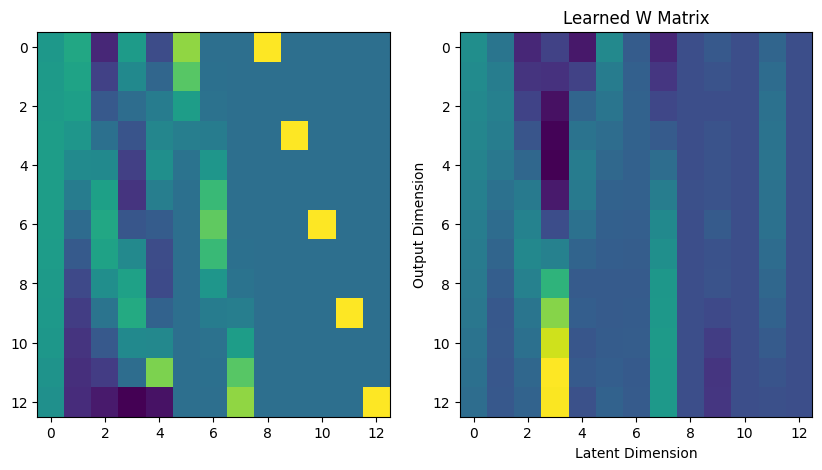

In [15]:
# Learned W Matrix
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# plot the W matrix
ax[0].imshow(W_init, aspect="auto")
ax[1].imshow(mf_gp.kernel.W.numpy(), aspect="auto")
# ax[0].set_colorbar()
plt.title("Learned W Matrix")
plt.ylabel("Output Dimension")
plt.xlabel("Latent Dimension")


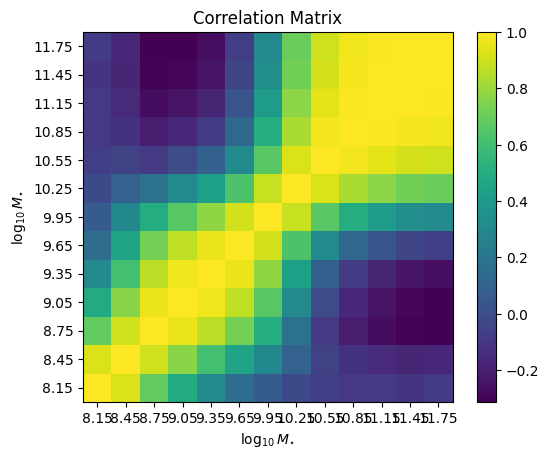

In [16]:
# Learned W Matrix
# plot the W matrix
# plt.imshow(mf_gp.kernel.W.numpy(), aspect="auto")
# plt.colorbar()
# plt.title("Learned W Matrix")
# plt.ylabel("Output Dimension")
# plt.xlabel("Latent Dimension")

K = mf_gp.kernel.W.numpy() @ mf_gp.kernel.W.numpy().T
# make it correlation matrix
D = np.diag(1/np.sqrt(np.diag(K)))
K = D @ K @ D

# Make the lower left corner to be origin of the plot
plt.imshow(K, cmap="viridis", origin="lower", )
plt.colorbar()
# I want the log mass bins to be ticks and labels
plt.xticks(range(len(loader.log10M)), loader.log10M)
plt.yticks(range(len(loader.log10M)), loader.log10M)
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\log_{10}M_{\star}$")
plt.title("Correlation Matrix")
plt.show()


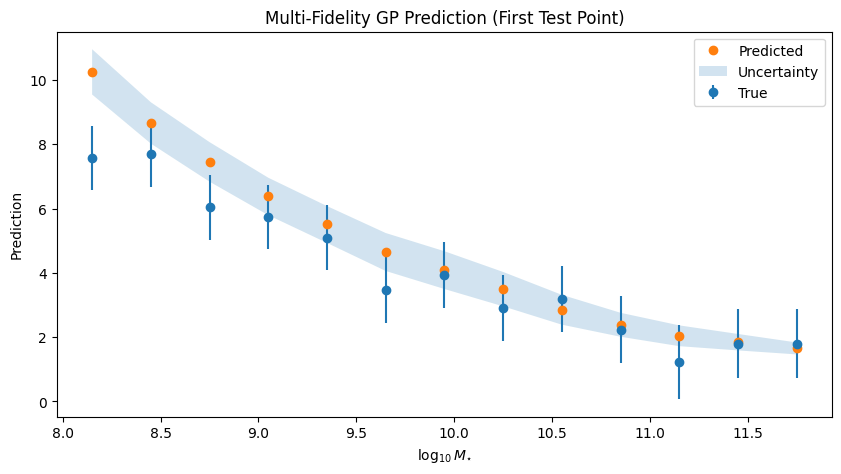

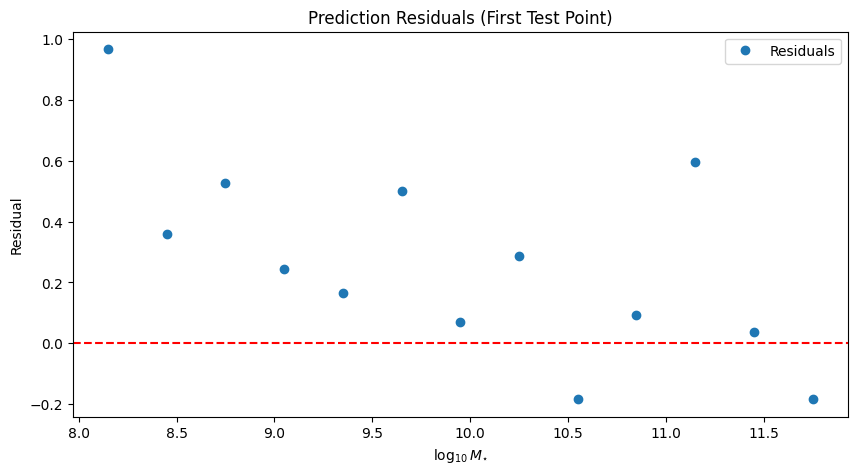

In [17]:
# Prediction
# 🔹 7️⃣ Plot Predictions vs Ground Truth
import matplotlib.pyplot as plt

stats = {"mu" : loader.Y256_stats["mu"][:len(loader.log10M)], "sd": loader.Y256_stats["sd"][:len(loader.log10M)]}

plt.figure(figsize=(10, 5))
plt.errorbar(loader.log10M,
             invert_standardizer(Y_test_HF[0], stats),
             yerr=loader.sigma_A256[test_start, :len(loader.log10M)],
             fmt='o', label="True")
plt.plot(loader.log10M,
         invert_standardizer(mean_pred.numpy()[0], stats),
         ls="",marker="o", label="Predicted")
plt.fill_between(
    loader.log10M,
    invert_standardizer((mean_pred.numpy()[0] - np.sqrt(var_pred.numpy()[0])), stats),
    invert_standardizer((mean_pred.numpy()[0] + np.sqrt(var_pred.numpy()[0])), stats),
    alpha=0.2, label="Uncertainty"
)

plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel("Prediction")
plt.legend()
plt.title("Multi-Fidelity GP Prediction (First Test Point)")
plt.show()

# 🔹 8️⃣ Residual Plot
plt.figure(figsize=(10, 5))
plt.plot(loader.log10M, residuals[0], marker="o", ls="", label="Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel("Residual")
plt.legend()
plt.title("Prediction Residuals (First Test Point)")
plt.show()

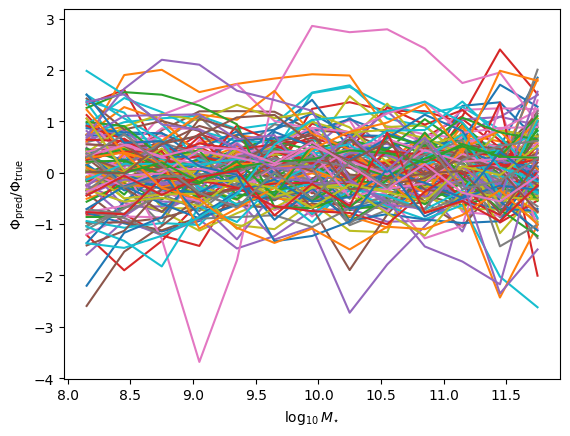

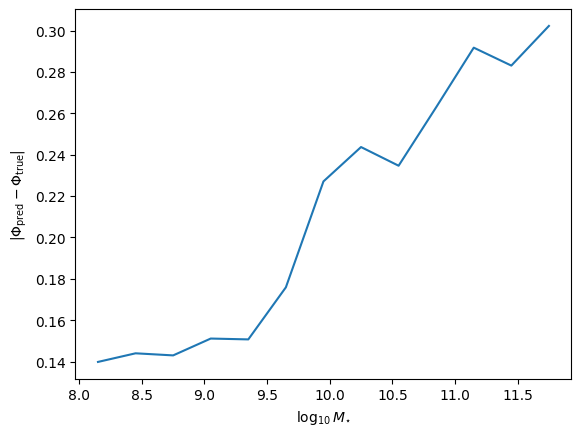

In [18]:
# plt.plot(loader.log10M, (mean_pred - Y_test_HF).numpy().T);
plt.plot(loader.log10M, (mean_pred - Y_test_HF).numpy().T);
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\Phi_{\mathrm{pred}}/\Phi_{\mathrm{true}}$")
plt.show()
# absolute error
relative_error = np.abs(invert_standardizer(mean_pred, stats) / invert_standardizer(Y_test_HF, stats) - 1)
plt.plot(loader.log10M, relative_error.mean(axis=0));
# plt.fill_between(loader.log10M, relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.plot(relative_error.mean(axis=0));
# plt.fill_between(relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.ylim(0, 0.5)
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$|\Phi_{\mathrm{pred}}-\Phi_{\mathrm{true}}|$")
plt.show()

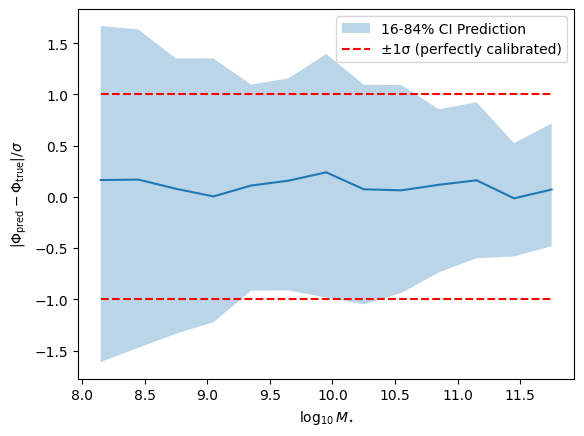

In [43]:
# Difference plot
relative_error = ((invert_standardizer(mean_pred, stats) - invert_standardizer(Y_test_HF, stats)).numpy()
                  ) / (np.sqrt(Var_test_HF + var_pred.numpy()) * stats["sd"])
plt.plot(loader.log10M, relative_error.mean(axis=0));
# 16 and 84 percentiles
q16, q50, q84 = np.percentile(relative_error, [16, 50, 84], axis=0)
plt.fill_between(loader.log10M, q16, q84, alpha=0.3, label="16-84% CI Prediction")
# plt.plot(relative_error.mean(axis=0));
# plt.fill_between(relative_error.min(axis=0), relative_error.max(axis=0), alpha=0.3)
# plt.ylim(0, 0.5)
plt.hlines([-1, 1], min(loader.log10M), max(loader.log10M), color='r', ls='--', label="±1σ (perfectly calibrated)")
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$|\Phi_{\mathrm{pred}}-\Phi_{\mathrm{true}}| / \sigma$")
plt.legend()
plt.show()

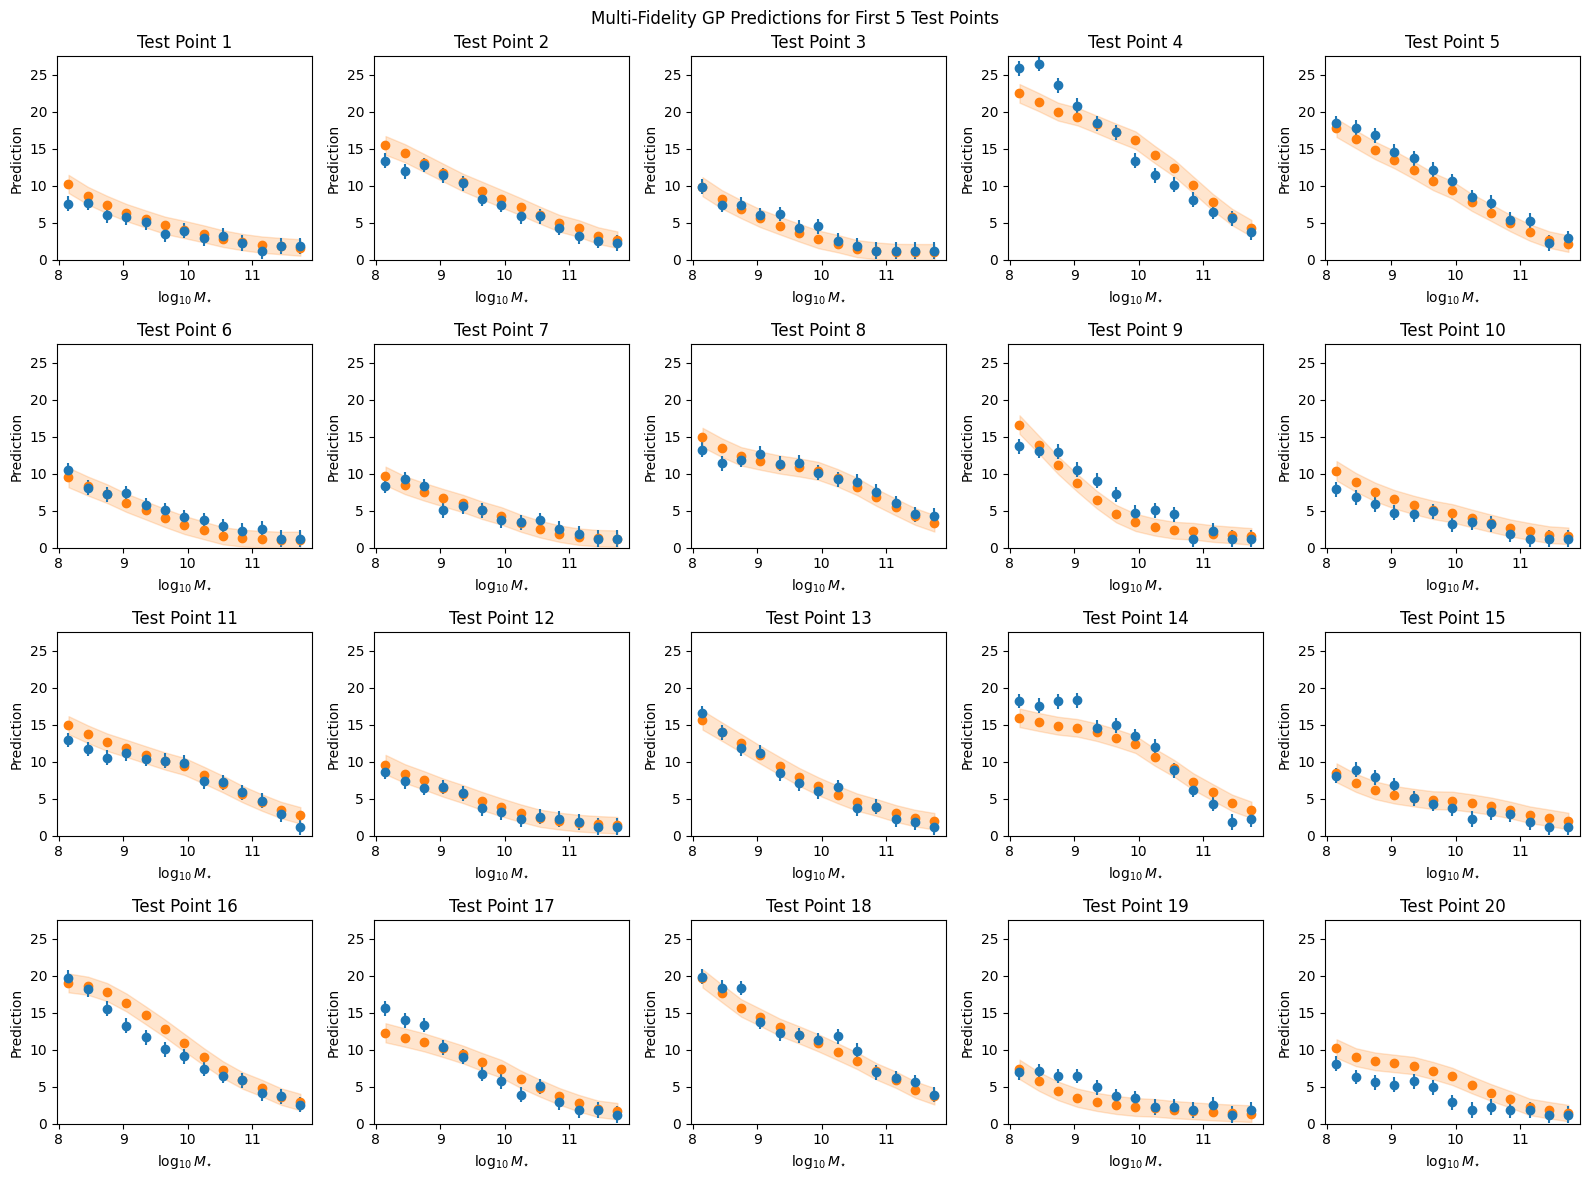

In [20]:
# a few predictions
fig, ax = plt.subplots(4, 5, figsize=(16, 12))

ax = ax.flatten()
for test_ind in range(20):
    # test_ind = 0  # Change this to select different test points
    ax[test_ind].errorbar(
        loader.log10M, 
        invert_standardizer(Y_test_HF[test_ind], stats),
        yerr=loader.sigma_A256[test_start + test_ind, :len(loader.log10M)],
        fmt='o', label="True")
    ax[test_ind].plot(loader.log10M, invert_standardizer(mean_pred.numpy()[test_ind], stats), ls="",marker="o", label="Predicted")
    ax[test_ind].fill_between(
        loader.log10M,
        invert_standardizer((mean_pred.numpy()[test_ind] - np.sqrt(var_pred.numpy()[test_ind] + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        invert_standardizer((mean_pred.numpy()[test_ind] + np.sqrt(var_pred.numpy()[test_ind] +  + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        alpha=0.2, label="Uncertainty", color='C1'
    )
    

    ax[test_ind].set_xlabel(r"$\log_{10}M_{\star}$")
    ax[test_ind].set_ylabel("Prediction")
    ax[test_ind].set_title(f"Test Point {test_ind + 1}")

    ax[test_ind].set_ylim(0, 27.5)
plt.suptitle("Multi-Fidelity GP Predictions for First 5 Test Points")
plt.tight_layout()



In [21]:
from mfgpflow.sb28_smf_loader import anscombe_to_phi

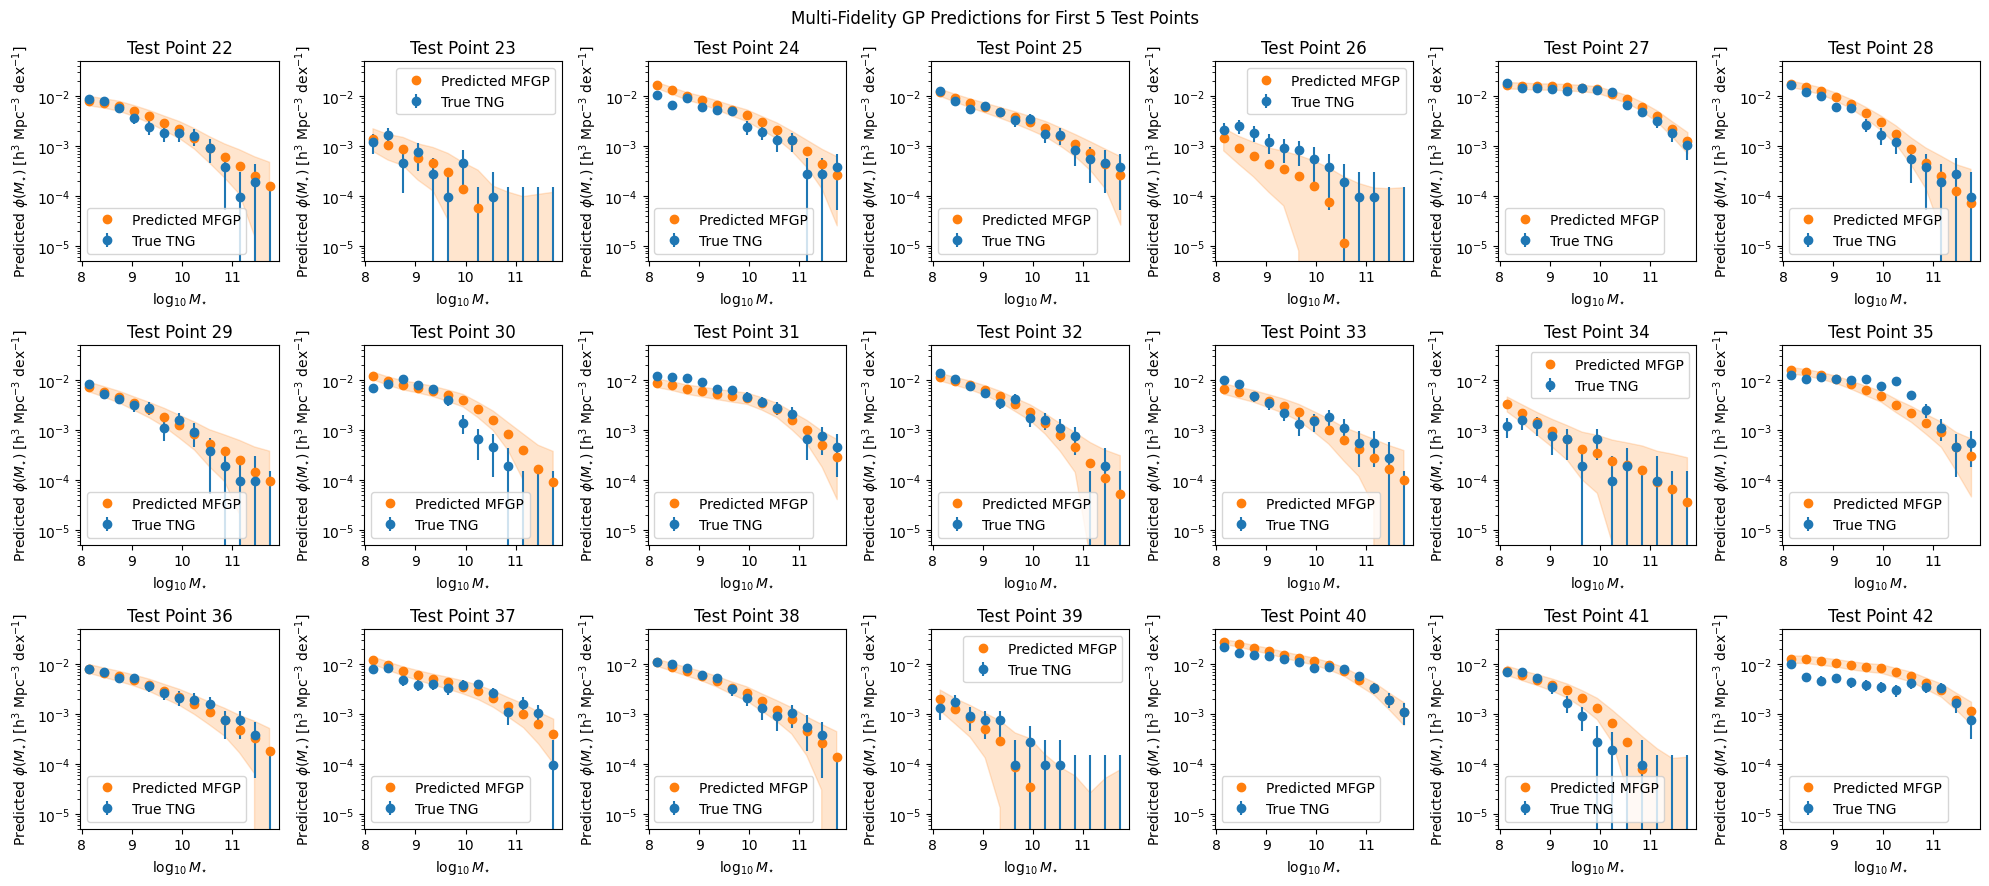

In [22]:
# a few predictions: Phi space
fig, ax = plt.subplots(3, 7, figsize=(20, 9))

ax = ax.flatten()
for i, test_ind in enumerate(range(21, 42)):
    # test_ind = 0  # Change this to select different test points
    phiA, VarA = anscombe_to_phi(invert_standardizer(Y_test_HF[test_ind], stats),
                    loader.sigma_A256[test_start + test_ind, :len(loader.log10M)],
                    dlog10M=loader.dlog10M,
                    Lbox=loader.Lbox
                    )
    ax[i].errorbar(
        loader.log10M, phiA,
        yerr=loader.sigma_phi256_total[test_start + test_ind, :len(loader.log10M)],
        fmt='o', label="True TNG")
    phiA, VarA = anscombe_to_phi(invert_standardizer(mean_pred.numpy()[test_ind], stats), 
                                 var_pred.numpy()[test_ind] + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2,
                                 dlog10M=loader.dlog10M,
                                 Lbox=loader.Lbox
                                 )
    ax[i].plot(
        loader.log10M, phiA, ls="",marker="o", label="Predicted MFGP"
    )
    lowerA, _ = anscombe_to_phi(
        invert_standardizer((mean_pred.numpy()[test_ind] - np.sqrt(var_pred.numpy()[test_ind] + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        var_pred.numpy()[test_ind] + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2,
        dlog10M=loader.dlog10M,
        Lbox=loader.Lbox
    )
    higherA, _ = anscombe_to_phi(
        invert_standardizer((mean_pred.numpy()[test_ind] + np.sqrt(var_pred.numpy()[test_ind] + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2 )), stats),
        var_pred.numpy()[test_ind] + loader.sigma_A256_standardized.mean(axis=0)[:len(loader.log10M)]**2,
        dlog10M=loader.dlog10M,
        Lbox=loader.Lbox
    )   
    ax[i].fill_between(
        loader.log10M,
        lowerA,
        higherA,
        alpha=0.2, #label="Uncertainty",
        color='C1'
    )
    

    ax[i].set_xlabel(r"$\log_{10}M_{\star}$")
    ax[i].set_ylabel("Predicted $\phi(M_{\star}) $ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
    ax[i].set_title(f"Test Point {test_ind + 1}")

    ax[i].set_ylim(5e-6, 5e-2)
    ax[i].set_yscale('log')
    ax[i].legend()
plt.suptitle("Multi-Fidelity GP Predictions for First 5 Test Points")
plt.tight_layout()


## Hyperparameters examination 

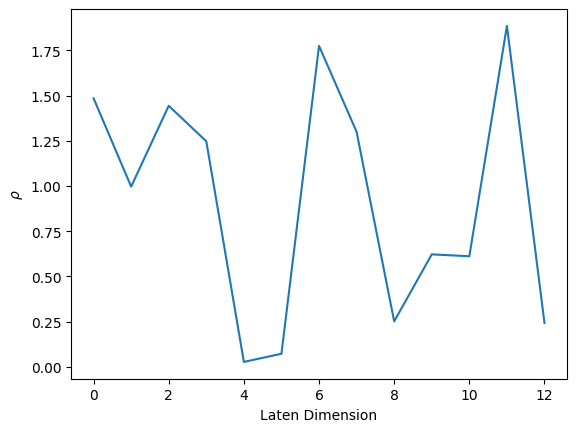

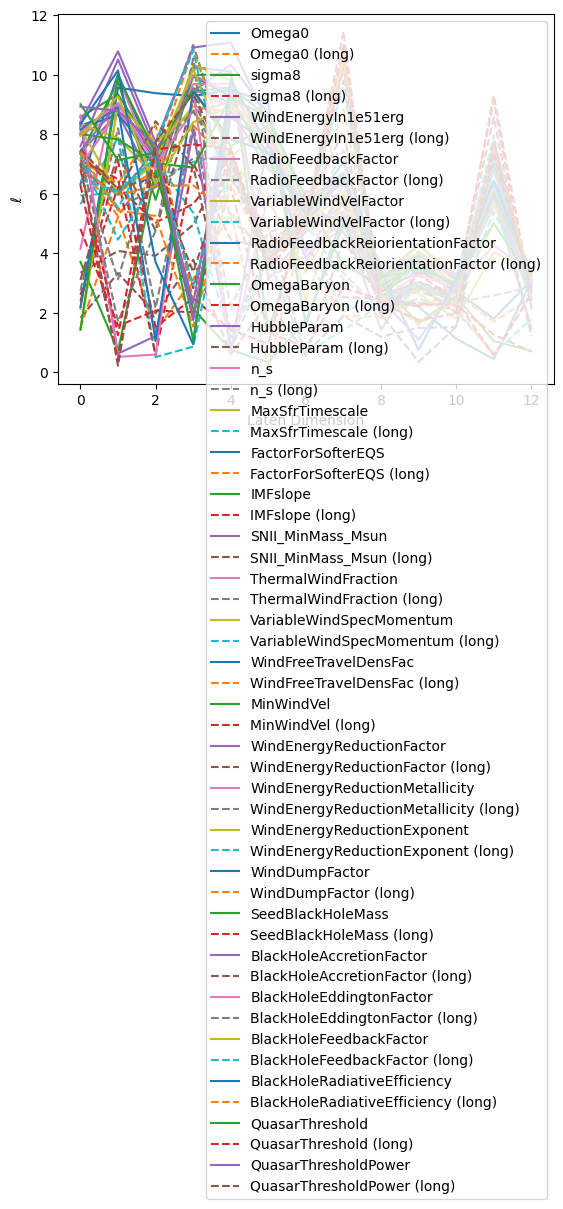

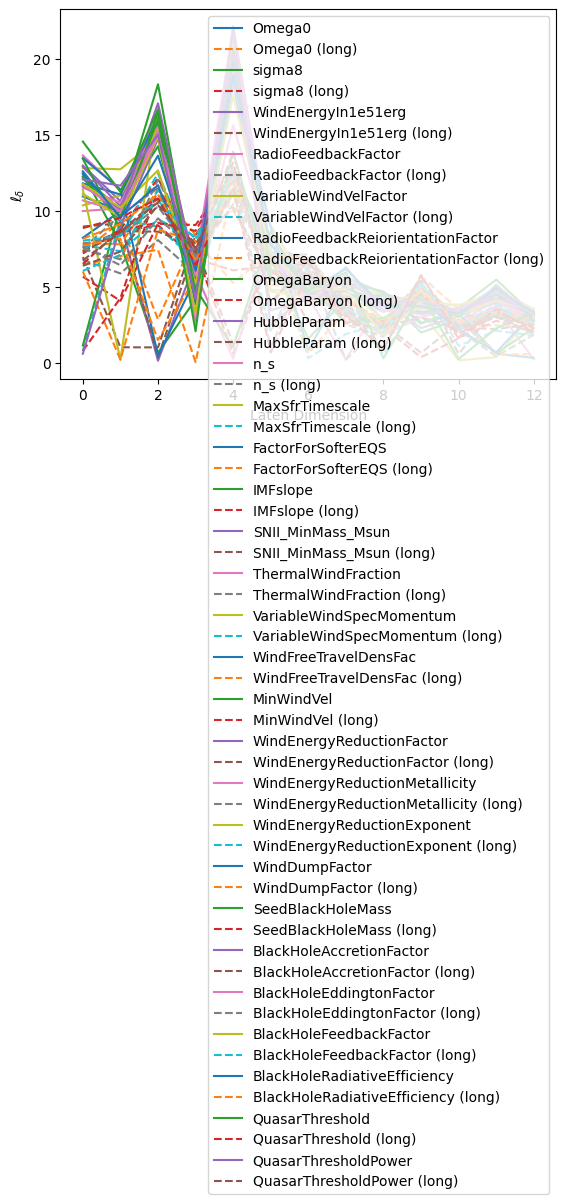

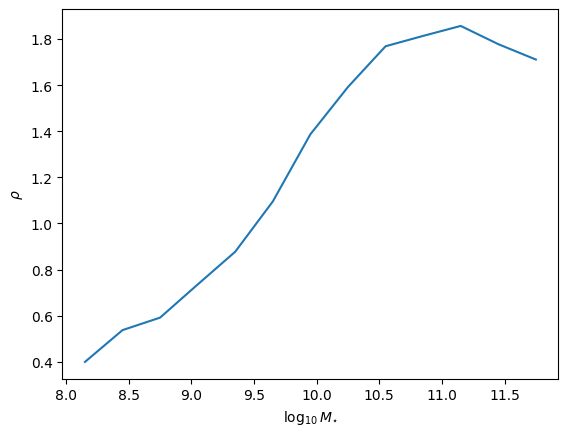

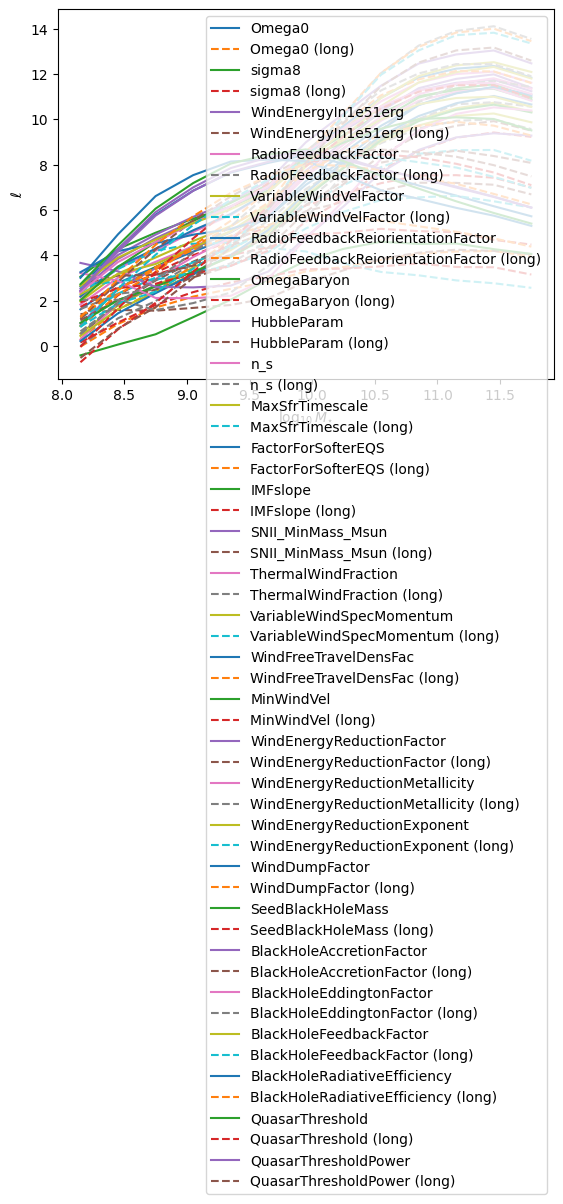

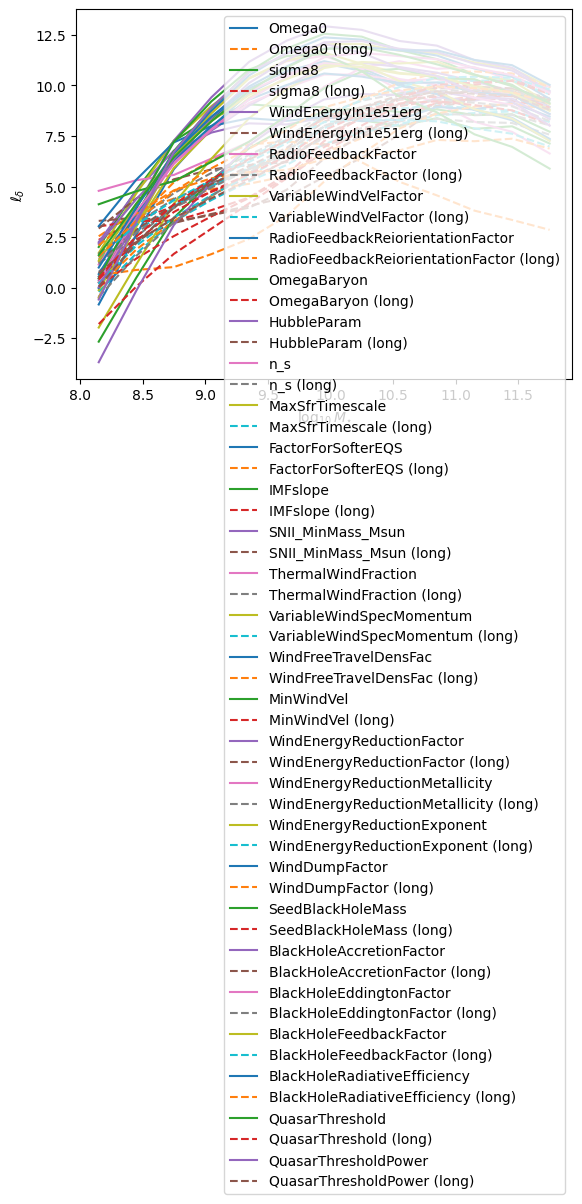

In [24]:
num_outputs = len(mf_gp.kernel.kernels)

# Extract the learned parameters
param_names = loader.param_names_[:28]
rho_values = []
lengthscale_values_long = []
lengthscale_delta_values_long = []
lengthscale_values_short = []
lengthscale_delta_values_short = []

for i in range(num_outputs):
    rho_values.append(mf_gp.kernel.kernels[i].rho.numpy()[0])
    lengthscale_values_long.append(mf_gp.kernel.kernels[i].kernel_L.kernels[0].lengthscales.numpy())
    lengthscale_delta_values_long.append(mf_gp.kernel.kernels[i].kernel_delta.kernels[0].lengthscales.numpy())
    lengthscale_values_short.append(mf_gp.kernel.kernels[i].kernel_L.kernels[1].lengthscales.numpy())
    lengthscale_delta_values_short.append(mf_gp.kernel.kernels[i].kernel_delta.kernels[1].lengthscales.numpy())

plt.plot(range(num_latents), rho_values)
plt.xlabel(r"Laten Dimension")
plt.ylabel(r"$\rho$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(range(num_latents), np.array(lengthscale_values_short)[:, i], label=param_name)
    plt.plot(range(num_latents), np.array(lengthscale_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"Laten Dimension")
plt.legend()
plt.ylabel(r"$\ell$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(range(num_latents), np.array(lengthscale_delta_values_short)[:, i], label=param_name)
    plt.plot(range(num_latents), np.array(lengthscale_delta_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"Laten Dimension")
plt.ylabel(r"$\ell_{\delta}$")
plt.legend()
plt.show()

# Projected rho values
projected_rho = mf_gp.kernel.W.numpy() @ np.array(rho_values)
plt.plot(loader.log10M, projected_rho[:, 0])
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\rho$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_values_short)[:, i], label=param_name)
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.legend()
plt.ylabel(r"$\ell$")
plt.show()

for i,param_name in enumerate(param_names):
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_delta_values_short)[:, i], label=param_name)
    plt.plot(loader.log10M, mf_gp.kernel.W.numpy() @ np.array(lengthscale_delta_values_long)[:, i], ls='--', label=param_name + " (long)")
plt.xlabel(r"$\log_{10}M_{\star}$")
plt.ylabel(r"$\ell_{\delta}$")
plt.legend()
plt.show()


## Diagnosis

In [52]:
import numpy as np

def pca_cov(Y, K=None):
    # Y: (N,P), already standardized per bin across LF∪HF
    C = np.cov(Y, rowvar=False)
    w, U = np.linalg.eigh(C)               # ascending
    idx = np.argsort(w)[::-1]              # descending
    w, U = w[idx], U[:, idx]
    if K is not None:
        U = U[:, :K]
    return C, w, U

def subspace_principal_angles(Ua, Ub):  # Ua, Ub: (P,K) with orthonormal cols
    # cos(angles) = svd(Ua^T Ub)
    _, s, _ = np.linalg.svd(Ua.T @ Ub, full_matrices=False)
    s = np.clip(s, 0, 1)
    return np.arccos(s)  # radians

def cov_shape_distance(Ca, Cb):
    # Compare *shapes* (ignore overall scale): Frobenius dist on trace-normalized
    Ca = Ca / np.trace(Ca)
    Cb = Cb / np.trace(Cb)
    return np.linalg.norm(Ca - Cb, ord='fro')

# Example use:
# Y128_std, Y256_std, Y512_std: standardized with SAME (mu, sd) from LF∪HF combined
K = 6  # compare first ~half of P
C128, w128, U128 = pca_cov(loader.Y128, K)
C512, w512, U512 = pca_cov(loader.Y256, K)
angles = subspace_principal_angles(U128, U512)  # small angles = aligned
shape_d = cov_shape_distance(C128, C512)
print("principal angles (deg):", np.degrees(angles))
print("cov shape distance (Fro):", shape_d)

principal angles (deg): [ 1.12129503  1.81765629  2.49104073  3.34269088 11.187605   26.39477255]
cov shape distance (Fro): 0.11839799364328128


In [54]:
# After training:
W = mf_gp.kernel.W.numpy()            # (P, L)
Sigma_model = W @ W.T                 # (P, P) model-implied output cov (up to kernel scales)

# Data-driven:
C128, _, _ = pca_cov(loader.Y128[:, :13])        # empirical cov
C512, _, _ = pca_cov(loader.Y256[:, :13])

# Compare shapes to model:
def align_dist(C, S):
    Cn = C / np.trace(C); Sn = S / np.trace(S)
    return np.linalg.norm(Cn - Sn, 'fro')

print("dist(model, LF):", align_dist(C128, Sigma_model))
print("dist(model, HF):", align_dist(C512, Sigma_model))

dist(model, LF): 0.5842564995180647
dist(model, HF): 0.676140767078512


In [55]:
mf_gp

name,class,transform,prior,trainable,shape,dtype,value
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[0].variance,Parameter,Softplus,,True,(),float64,3.09975
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[0].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[1.49204, 2.59615, 1.82561..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[1].variance,Parameter,Softplus,,True,(),float64,0.04726
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_L.kernels[1].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[6.31953, 8.56874, 7.59136..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[0].variance,Parameter,Softplus,,True,(),float64,1.29366
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[0].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[7.36462, 7.61921, 6.98001..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[1].variance,Parameter,Softplus,,True,(),float64,0.1871
LatentMFCoregionalizationSVGP.kernel.kernels[0].kernel_delta.kernels[1].lengthscales,Parameter,Softplus,,True,"(28,)",float64,"[10.96829, 12.50204, 12.30091..."
LatentMFCoregionalizationSVGP.kernel.kernels[0].rho,Parameter,Softplus,,True,"(1, 1)",float64,[[1.48507]]
LatentMFCoregionalizationSVGP.kernel.kernels[1].kernel_L.kernels[0].variance,Parameter,Softplus,,True,(),float64,0.40783
